# README: ESIM + DistilBERT Model for Claim-Evidence Classification

This notebook implements an ESIM (Enhanced Sequential Inference Model) + DistilBERT hybrid model for claim-evidence classification. The model uses distilBERT to create contextual embeddings, that later get fed to the ESIM.

It covers the following sections:

1.  **Installations, Imports and Constants**: Sets up the environment.
2.  **Environment Setup**: Defines the custom PyTorch Dataset and the ESIMWithBERT model architecture, and loads the distilBERT tokenizer for contextual embeddings.
3.  **Training Loop**: Contains the code for training the model.
4.  **Load Saved Model**: Loads the saved model file to prevent re-training
5.  **Evaluation**: Evaluates the trained model on the validation set and displays various metrics including a confusion matrix and error analysis.
6.  **Error Analysis**: Specifically focuses on displaying misclassified examples.
7.  **McNamer Test**: Performs a McNemar test to compare this model's performance against another proposed model, assuming its predictions are available.
8.  **Demo Code**: Get predictions for different dataset and save them to a CSV file.


### How to Run This Notebook:
* **Make sure to upload the training, validation and test dataset in the content folder before running the entire notebook.**

* If dataset file names are different to the ones stated in the `Constants` Section, then change names appropriately in the `Constants` Section.

* To run the entire notebook, execute cells sequentially. However, if you want to use the trained model to evaluate, then don't run Section 4 (`Load Saved Model`).
* Model has already been trained and stored in Google Drive with public access using this link: `https://drive.google.com/uc?id=15PzifMWjkViZvRUp48ntNg5B2FHaHN77`

### Running Sections:

*   **To run Training (Section 3):**
    *   Make sure to have uploaded the Training Dataset in the content folder
    *   Run Cells in Section 1 (Installations, Imports and Constants).
    *   Run Cells in Section 2 (Environment Setup).
    *   Run Cells in Section 3 (Training Loop).

*   **To run Evaluation (Section 5):**
    *   Make sure to have uploaded the Validation/dev Dataset in the content folder
    *   Run Cells in Section 1 (Installations, Imports and Constants).
    *   Run Cells in Section 2 (Environment Setup).
    *   IF model has NOT been trained (Section 3):
        - Run Cells in Section 4 (Load Saved Model) to load the saved model. The cell in Section 4 will attempt to download (`esim_bert_model.pt`) using `gdown`, using the shared link for the model file.
    * IF model HAS been trained (Section 3):
        - Run Evaluation Section 5 as normal
    *   Run Cells in Section 5 (Evaluation).

*   **To run Error Analysis (Section 6):**
    *   First, complete the Evaluation Section 5.
    *   Run Cells in Section 6 (Error Analysis).

*   **To run McNemar Test (Section 7):**
    *   First, complete the Evaluation Section 5.
    *   **Ensure `predictionsDEV2.csv` (predictions from the other model) are uploaded/available.**
    *   Run Cells in Section 7 (McNamer Test).

*   **To run Demo Code (Section 8) on the test dataset:**
    *   Make sure to have uploaded the Test Dataset in the content folder
    *   Run Cells in Section 1 (Installations, Imports and Constants).
    *   Run Cells in Section 2 (Environment Setup).
    *   Either load the saved model in Section 4 (`esim_bert_model.pt`) or use the trained model from Section 3 (if Training Section has been done/run).
    *   Run Cells in Section 8 (Demo Code).


###The base model files are below:
* base_model_repo = 'https://github.com/coetaur0/ESIM',
* base_model_paper = 'https://aclanthology.org/P17-1152.pdf',

##1. Installations, Imports and Constants

In [1]:
# Installations
!pip install pandas scikit-learn --quiet
!pip install tensorflow --quiet
!pip install gensim --quiet
!pip install --upgrade transformers[sentencepiece] --quiet


# Imports
import pandas as pd
import numpy as np
import random
import nltk
import tensorflow as tf
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from scipy.stats import chi2
import re
import torch.nn.functional as F
from tqdm import tqdm
import math
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)
# Mount drive to save model after training and load model
#drive.mount('/content/drive')



# Constants
CHECKPOINT = "distilbert-base-uncased"
MAX_LEN_CLAIM = 100
MAX_LEN_EVIDENCE = 300
BATCH_SIZE = 32
NUM_CLASSES = 2
HIDDEN_SIZE = 128
COMPOSE_HIDDEN = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAINING_SET = '/content/train.csv'
VALIDATION_SET = '/content/dev.csv'



# !!!!!! Change for different test dataset !!!!!!
TEST_SET = '/content/test.csv'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.1 MB/s eta 0:00:00


##2. Environment Setup

In [5]:
# Custom PyTorch Dataset for claim–evidence classification
# Handles tokenization and formatting of inputs for the ESIM + DistilBERT model

class ClaimEvidenceDataset(Dataset):
    def __init__(self, claims, evidences, tokenizer, labels=None):
        self.claims = claims
        self.evidences = evidences
        self.labels = labels
        self.tokenizer = tokenizer

    # Returns the total number of claim–evidence pairs
    def __len__(self):
        return len(self.claims)

    # Retrieve claim and evidence text at index idx
    def __getitem__(self, idx):
        claim = self.claims[idx]
        evidence = self.evidences[idx]

        # Separate encodings (ESIM)
        claim_enc = self.tokenizer(
            claim,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN_CLAIM,
            return_tensors='pt'
        )

        evidence_enc = self.tokenizer(
            evidence,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN_EVIDENCE,
            return_tensors='pt'
        )

        # Encode the claim–evidence pair together
        # This produces the cross-encoded representation used by DistilBERT
        # to capture interactions between the two sequences
        pair_enc = self.tokenizer(
            claim,
            evidence,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )

        # Construct dictionary of tensors returned for each example
        item = {
            'claim_input_ids': claim_enc['input_ids'].squeeze(0),
            'claim_attention_mask': claim_enc['attention_mask'].squeeze(0),

            'evidence_input_ids': evidence_enc['input_ids'].squeeze(0),
            'evidence_attention_mask': evidence_enc['attention_mask'].squeeze(0),

            'pair_input_ids': pair_enc['input_ids'].squeeze(0),
            'pair_attention_mask': pair_enc['attention_mask'].squeeze(0)
        }

        if self.labels is not None:
            item['label'] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item




"""
Hybrid ESIM + DistilBERT model for claim-evidence classification.

Structure:
- DistilBERT provides contextual embeddings for claims, evidences, and their pair.
- ESIM BiLSTM layers encode claim and evidence sequences independently.
- Attention mechanism aligns claims ↔ evidences.
- Enhanced representations are composed with another BiLSTM.
- Outputs pooled representations + BERT [CLS] token into a classifier.
"""
class ESIMWithBERT(nn.Module):

    def __init__(self, checkpoint=CHECKPOINT, hidden_size=HIDDEN_SIZE, compose_hidden=COMPOSE_HIDDEN, num_classes=NUM_CLASSES):
        super().__init__()

        # distilBERT
        self.bert = AutoModel.from_pretrained(checkpoint)

        # ESIM layers
        self.encode_bilstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        self.compose_bilstm = nn.LSTM(
            input_size=8 * hidden_size,
            hidden_size=compose_hidden,
            batch_first=True,
            bidirectional=True
        )

        # Classifier
        self.fc1 = nn.Linear(8 * compose_hidden + self.bert.config.hidden_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc_out = nn.Linear(128, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    # Masked pooling functions
    def masked_mean(self, tensor, mask):
        mask = mask.unsqueeze(-1).float()
        return (tensor * mask).sum(dim=1) / mask.sum(dim=1)

    def masked_max(self, tensor, mask):
        mask = mask.unsqueeze(-1)
        tensor = tensor.masked_fill(mask == 0, -1e9)
        return tensor.max(dim=1)[0]

    def forward(self, claim_ids, claim_mask, evidence_ids, evidence_mask, pair_ids, pair_mask):

        # distilBERT embeddings (lower layer)
        claim_outputs = self.bert(
            input_ids=claim_ids,
            attention_mask=claim_mask,
            output_hidden_states=True
        )
        evidence_outputs = self.bert(
            input_ids=evidence_ids,
            attention_mask=evidence_mask,
            output_hidden_states=True
        )

        claim_emb = claim_outputs.hidden_states[-4]
        evidence_emb = evidence_outputs.hidden_states[-4]

        # Cross encoded BERT signal
        pair_inputs = self.bert(
            input_ids=pair_ids,
            attention_mask=pair_mask
        )

        pair_cls = pair_inputs.last_hidden_state[:, 0]

        # Encoding BiLSTM
        claim_encoded, _ = self.encode_bilstm(claim_emb)
        evidence_encoded, _ = self.encode_bilstm(evidence_emb)

        # Attention (masking)
        attention = torch.matmul(
            claim_encoded,
            evidence_encoded.transpose(1, 2)
        )

        # Claim → Evidence
        evidence_mask_exp = evidence_mask.unsqueeze(1)
        attention_c2e = attention.masked_fill(evidence_mask_exp == 0, -1e9)
        claim_att = torch.softmax(attention_c2e, dim=-1)

        # Evidence → Claim
        attention_e2c = attention.transpose(1, 2)
        claim_mask_exp = claim_mask.unsqueeze(1)
        attention_e2c = attention_e2c.masked_fill(claim_mask_exp == 0, -1e9)
        evidence_att = torch.softmax(attention_e2c, dim=-1)

        # Alignments
        aligned_evidence = torch.matmul(claim_att, evidence_encoded)
        aligned_claim = torch.matmul(evidence_att, claim_encoded)

        # Enhanced representations
        claim_enh = torch.cat([
            claim_encoded,
            aligned_evidence,
            claim_encoded - aligned_evidence,
            claim_encoded * aligned_evidence
        ], dim=-1)

        evidence_enh = torch.cat([
            evidence_encoded,
            aligned_claim,
            evidence_encoded - aligned_claim,
            evidence_encoded * aligned_claim
        ], dim=-1)

        # Composition BiLSTM
        claim_comp, _ = self.compose_bilstm(claim_enh)
        evidence_comp, _ = self.compose_bilstm(evidence_enh)

        # Masked Pooling
        claim_avg = self.masked_mean(claim_comp, claim_mask)
        claim_max = self.masked_max(claim_comp, claim_mask)

        evidence_avg = self.masked_mean(evidence_comp, evidence_mask)
        evidence_max = self.masked_max(evidence_comp, evidence_mask)

        merged = torch.cat([
            claim_avg, claim_max,
            evidence_avg, evidence_max
        ], dim=-1)

        # BERT CLS residual
        merged = torch.cat([merged, pair_cls], dim=-1)

        # Classifier
        x = self.dropout(self.relu(self.fc1(merged)))
        x = self.dropout(self.relu(self.fc2(x)))

        logits = self.fc_out(x)
        return logits


# Load the contextual embedding tokenizer
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

##3. Training Loop
Before running this cell, run cell 1 and 2.

In [6]:
# Load training dataset and validation dataset for epoch metrics
training = pd.read_csv(TRAINING_SET)
validation = pd.read_csv(VALIDATION_SET)

# Create custom datasets for training and validation
train_dataset = ClaimEvidenceDataset(training['Claim'].tolist(),
                                     training['Evidence'].tolist(),
                                     tokenizer,
                                     labels=training['label'].tolist())

val_dataset = ClaimEvidenceDataset(validation['Claim'].tolist(),
                                   validation['Evidence'].tolist(),
                                   tokenizer,
                                   labels=validation['label'].tolist())

# Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


best_val_f1 = 0 # Initialize best F1 score for saving the best model

# Instantiate the model and move it to the appropriate device (CPU/GPU)
model = ESIMWithBERT().to(DEVICE)

# Initialize the Adam optimizer for model parameters
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# Define the number of training epochs
EPOCHS = 4

# Training Loop
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Set model to training mode
    model.train()
    train_loss = 0
    train_acc = 0

    # Iterate over batches in the training data
    for batch in tqdm(train_loader, desc="Training", ncols=100):
        optimizer.zero_grad() # Zero out gradients before each batch

        # Move all batch inputs and labels to the specified device
        claim_ids = batch['claim_input_ids'].to(DEVICE)
        claim_mask = batch['claim_attention_mask'].to(DEVICE)
        evidence_ids = batch['evidence_input_ids'].to(DEVICE)
        evidence_mask = batch['evidence_attention_mask'].to(DEVICE)

        pair_ids = batch['pair_input_ids'].to(DEVICE)
        pair_mask = batch['pair_attention_mask'].to(DEVICE)

        labels = batch['label'].to(DEVICE)

        # Forward pass: get model logits
        logits = model(
            claim_ids, claim_mask,
            evidence_ids, evidence_mask,
            pair_ids, pair_mask  # pass pair inputs for BERT
        )

        # Calculate loss and perform backpropagation
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step() # Update model parameters

        # Accumulate training loss and accuracy
        train_loss += loss.item() * claim_ids.size(0)
        train_acc += (logits.argmax(dim=1) == labels).sum().item()

    # Calculate average training loss and accuracy for the epoch
    train_loss /= len(train_dataset)
    train_acc /= len(train_dataset)

    # Validation Phase
    model.eval() # Set model to evaluation mode
    val_loss = 0
    val_acc = 0

    all_preds = []
    all_labels = []

    # Disable gradient calculation for validation
    with torch.no_grad():
        for batch in val_loader:
            claim_ids = batch['claim_input_ids'].to(DEVICE)
            claim_mask = batch['claim_attention_mask'].to(DEVICE)
            evidence_ids = batch['evidence_input_ids'].to(DEVICE)
            evidence_mask = batch['evidence_attention_mask'].to(DEVICE)

            pair_ids = batch['pair_input_ids'].to(DEVICE)
            pair_mask = batch['pair_attention_mask'].to(DEVICE)

            labels = batch['label'].to(DEVICE)

            # Forward pass for validation
            logits = model(
                claim_ids, claim_mask,
                evidence_ids, evidence_mask,
                pair_ids, pair_mask
            )

            # Calculate validation loss
            loss = F.cross_entropy(logits, labels)

            # Accumulate validation loss and accuracy
            val_loss += loss.item() * claim_ids.size(0)
            val_acc += (logits.argmax(dim=1) == labels).sum().item()

            # Store predictions and true labels for F1 score calculation
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate average validation loss and accuracy for the epoch
    val_loss /= len(val_dataset)
    val_acc /= len(val_dataset)

    # Calculate weighted F1 score for validation
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    # Print epoch statistics
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Save the model if current validation F1 score is better than the best so far
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pt") # Save model state dictionary
        print("Saved best model to Drive")

# Load the state dictionary of the best model found during training
model.load_state_dict(torch.load("best_model.pt"))
print(f"\n Best Weighted F1: {best_val_f1:.4f}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/4


Training:   7%|███▍                                                | 45/673 [01:53<26:20,  2.52s/it]


KeyboardInterrupt: 

##4. Load Saved Model
Run this if `Training Loop` cell has not been run.

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model saved on drive using shared link for faster access
!gdown https://drive.google.com/uc?id=15PzifMWjkViZvRUp48ntNg5B2FHaHN77

model = ESIMWithBERT().to(DEVICE)
model.load_state_dict(torch.load("esim_bert_model.pt", map_location=DEVICE))

Downloading...
From (original): https://drive.google.com/uc?id=15PzifMWjkViZvRUp48ntNg5B2FHaHN77
From (redirected): https://drive.google.com/uc?id=15PzifMWjkViZvRUp48ntNg5B2FHaHN77&confirm=t&uuid=df5087c3-e673-4166-bf0b-ff1b8e909741
To: /content/esim_bert_model.pt
100% 283M/283M [00:03<00:00, 82.5MB/s]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

##5. Evaluation
Run Section 1, 2 and 3/4 (3 if you want to train the model, else 4 for loading saved model) before running this cell.




Weighted F1:        0.8673

Accuracy:               0.8670
Macro Precision:          0.8331
Macro Recall:             0.8364
Macro F1:                 0.8347
Weighted Precision:       0.8677
Weighted Recall:          0.8670
Matthews Corrcoef:        0.6695



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4286
           1       0.76      0.77      0.76      1640

    accuracy                           0.87      5926
   macro avg       0.83      0.84      0.83      5926
weighted avg       0.87      0.87      0.87      5926







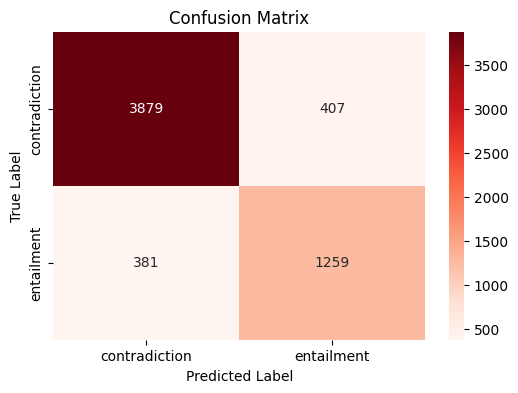

In [8]:
# Load the validation dataset
validation = pd.read_csv(VALIDATION_SET)

val_dataset = ClaimEvidenceDataset(validation['Claim'].tolist(),
                                   validation['Evidence'].tolist(),
                                   tokenizer,
                                   labels=validation['label'].tolist())

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# -----------------------------------------Evaluation Section-------------------------------------------------

# Evaluate the model on the validation dataset
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        claim_ids = batch['claim_input_ids'].to(DEVICE)
        claim_mask = batch['claim_attention_mask'].to(DEVICE)
        evidence_ids = batch['evidence_input_ids'].to(DEVICE)
        evidence_mask = batch['evidence_attention_mask'].to(DEVICE)

        # Add pair inputs
        pair_ids = batch['pair_input_ids'].to(DEVICE)
        pair_mask = batch['pair_attention_mask'].to(DEVICE)

        labels = batch['label'].to(DEVICE)

        logits = model(claim_ids, claim_mask, evidence_ids, evidence_mask, pair_ids, pair_mask)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())




# -----------------------------------------Metrics Section-------------------------------------------------

# Display metrics for the validation dataset

# Core metrics
accuracy = accuracy_score(all_labels, all_preds)

macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

weighted_precision = precision_score(all_labels, all_preds, average='weighted')
weighted_recall = recall_score(all_labels, all_preds, average='weighted')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

mcc = matthews_corrcoef(all_labels, all_preds)

# Print results
print(f"\n\n\nWeighted F1:        {weighted_f1:.4f}")
print(f"\nAccuracy:               {accuracy:.4f}")
print(f"Macro Precision:          {macro_precision:.4f}")
print(f"Macro Recall:             {macro_recall:.4f}")
print(f"Macro F1:                 {macro_f1:.4f}")
print(f"Weighted Precision:       {weighted_precision:.4f}")
print(f"Weighted Recall:          {weighted_recall:.4f}")
print(f"Matthews Corrcoef:        {mcc:.4f}")

# Diagnostic report
print("\n\n\nClassification Report:")
print(classification_report(all_labels, all_preds))
print("\n\n\n")



# -----------------------------------------Confusion Matrix Section-------------------------------------------------

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

cm_df = pd.DataFrame(cm, index=['contradiction', 'entailment'], columns=['contradiction', 'entailment'])

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

##6. Error Analysis
Run Section 5 before running this Section

In [9]:
# Look at 20 misclassed examples to analyse where the model struggles

misclassified_examples = []

for i in range(len(all_preds)):
    if all_preds[i] != all_labels[i]:
        misclassified_examples.append({
            'claim': validation['Claim'].iloc[i],
            'evidence': validation['Evidence'].iloc[i],
            'true_label': all_labels[i],
            'predicted_label': all_preds[i]
        })

print(f"\nFound {len(misclassified_examples)} misclassified examples.")

# Randomly pick up to 20 misclassified examples
num_to_show = min(20, len(misclassified_examples))
selected_misclassified = random.sample(misclassified_examples, num_to_show)

print(f"\nDisplaying {num_to_show} random misclassified examples:")
for i, example in enumerate(selected_misclassified):
    print(f"\n--- Example {i+1} ---")
    print(f"Claim: {example['claim']}")
    print(f"Evidence: {example['evidence']}")
    print(f"True Label: {example['true_label']}")
    print(f"Predicted Label: {example['predicted_label']}")


Found 788 misclassified examples.

Displaying 20 random misclassified examples:

--- Example 1 ---
Claim: We should end development aid
Evidence: Budgetary support from Australia and development aid under World Bank auspices have helped sustain the economy.
True Label: 0
Predicted Label: 1

--- Example 2 ---
Claim: Organic food should be prohibited.
Evidence: Using organic fertilizers can help decrease soil erosion and boost fertility by reducing the bulk density [REF].
True Label: 0
Predicted Label: 1

--- Example 3 ---
Claim: We should subsidize public transportation
Evidence: Since automobile use tends to be greater than public transportation use, it also becomes the norm for people to work towards car ownership.
True Label: 0
Predicted Label: 1

--- Example 4 ---
Claim: We should end mining
Evidence: The Northern Territory's economy is largely driven by mining, which is concentrated on energy producing minerals, petroleum and energy and contributes around $2.5 billion to the gross

##7. McNamer Test between the 2 models proposed for ED

!!! Before running this code the dev set predictions from the other prpoposed model need to be loaded onto Colab !!!

In [ ]:
# Load predictions

# ESIM + DistilBERT hybrid model
pred_A = np.loadtxt("ed_predictions.txt")

# DEBERTa with Attention Mechanism
pred_B = np.loadtxt("predictionsDEV2.csv", skiprows=1)

# Load gold labels
gold = np.array(all_labels) # Convert list to NumPy array

# Convert to integers
pred_A = pred_A.astype(int)
pred_B = pred_B.astype(int)
gold = gold.astype(int)

# Check sizes
print("Lengths:", len(pred_A), len(pred_B), len(gold))

# Correct/incorrect masks
a_correct = pred_A == gold
b_correct = pred_B == gold

# McNemar counts
n01 = np.sum((a_correct == True) & (b_correct == False))
n10 = np.sum((a_correct == False) & (b_correct == True))

# McNemar test
if (n01 + n10) > 0:
    chi2_stat = (abs(n01 - n10) - 1)**2 / (n01 + n10)
    p_value = 1 - chi2.cdf(chi2_stat, 1)
else:
    chi2_stat = 0.0
    p_value = 1.0

print("n01 (A correct, B wrong):", n01)
print("n10 (A wrong, B correct):", n10)
print("Chi-square:", chi2_stat)
print("p-value:", p_value)

##8. Demo Code

In [11]:
# Load the test dataset provided
test = pd.read_csv(TEST_SET)

# Tokenize the test dataset
test_dataset = ClaimEvidenceDataset(test['Claim'].tolist(),
                                   test['Evidence'].tolist(),
                                   tokenizer,
                                   labels=None)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Get model predictions for the test dataset
model.eval()
test_pred = []

with torch.no_grad():
    for batch in test_loader:
        claim_ids = batch['claim_input_ids'].to(DEVICE)
        claim_mask = batch['claim_attention_mask'].to(DEVICE)
        evidence_ids = batch['evidence_input_ids'].to(DEVICE)
        evidence_mask = batch['evidence_attention_mask'].to(DEVICE)

        # Add pair inputs
        pair_ids = batch['pair_input_ids'].to(DEVICE)
        pair_mask = batch['pair_attention_mask'].to(DEVICE)

        logits = model(claim_ids, claim_mask, evidence_ids, evidence_mask, pair_ids, pair_mask)
        preds = torch.argmax(logits, dim=1)

        test_pred.extend(preds.cpu().numpy())


# Convert the numpy array to a pandas DataFrame
preds_df = pd.DataFrame(test_pred, columns=['predictions'])

# Save the DataFrame to a CSV file
preds_df.to_csv("Group_54_B.csv", index=False)
print("Model predictions file created successfully: Group_54_B.csv")

# Display the split between class predictions
predictions_series = pd.Series(test_pred)
print("\n\nPredicted label distribution:")
display(predictions_series.value_counts().sort_index())

Model predictions file created successfully: Group_54_B.csv


Predicted label distribution:


,count
0,2792
1,1896
